## Final Evaluation
- Environment: ALE/MsPacman-v5
- Frame stacking: 4
- Avg score over 10 episodes: XXX
- Best episode score: XXX


In [1]:
'''DQN-Pacman/
│
├── README.md
├── requirements.txt
│
├── notebooks/
│   ├── DQN_Pacman_2_0.ipynb
│   └── DQN_Pacman_ablation.ipynb
│
├── models/
│   └── dqn_pacman_full.pth
│
├── videos/
│   └── pacman.mp4
│
└── images/
    ├── reward_curve.png
    ├── loss_curve.png
    └── q_values.png'''

'DQN-Pacman/\n│\n├── README.md\n├── requirements.txt\n│\n├── notebooks/\n│   ├── DQN_Pacman_2_0.ipynb\n│   └── DQN_Pacman_ablation.ipynb\n│\n├── models/\n│   └── dqn_pacman_full.pth\n│\n├── videos/\n│   └── pacman.mp4\n│\n└── images/\n    ├── reward_curve.png\n    ├── loss_curve.png\n    └── q_values.png'

In [2]:
!pip install -q gymnasium[atari,accept-rom-license]
!pip install -q ale-py
!pip install -q autorom

!AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asterix.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asteroids.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis2.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/backgammon.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/bank_heist.bin
Inst

In [3]:
import gymnasium as gym
import ale_py
import numpy as np
import random
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import matplotlib.pyplot as plt


In [4]:
env = gym.make(
    "ALE/MsPacman-v5",
    obs_type="rgb",
    frameskip=1,
    repeat_action_probability=0.0
)

print("Observation:", env.observation_space.shape)
print("Actions:", env.action_space.n)


Observation: (210, 160, 3)
Actions: 9


In [5]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

In [6]:
class FrameStacker:
    def __init__(self, k=4):
        self.k = k
        self.frames = deque(maxlen=k)

    def preprocess(self, frame):
        frame = np.array(frame)

        if frame.ndim == 3:
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

        frame = cv2.resize(frame, (84, 84))
        frame = frame.astype(np.float16) / 255.0
        return frame  # (84, 84)

    def reset(self, obs):
        frame = self.preprocess(obs)
        self.frames.clear()
        for _ in range(self.k):
            self.frames.append(frame)
        return np.stack(self.frames, axis=0)  # (4, 84, 84)

    def step(self, obs):
        frame = self.preprocess(obs)
        self.frames.append(frame)
        return np.stack(self.frames, axis=0)


In [7]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(7 * 7 * 64, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)  # SAFE
        return self.fc(x)


In [8]:
class ReplayBuffer:
    def __init__(self, capacity=5000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)
        return s, a, r, ns, d

    def __len__(self):
        return len(self.buffer)


In [9]:
class Agent:
    def __init__(self, n_actions, device):
        self.device = device
        self.q = DQN(n_actions).to(device)
        self.target = DQN(n_actions).to(device)
        self.target.load_state_dict(self.q.state_dict())

        self.optimizer = optim.Adam(self.q.parameters(), lr=1e-4)
        self.buffer = ReplayBuffer()

        self.gamma = 0.99
        self.batch_size = 32
        self.update_every = 1000
        self.step_count = 0

    def act(self, state, eps):
        if random.random() < eps:
            return random.randrange(env.action_space.n)
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.q(state).argmax(1).item()

    def learn(self):
      if len(self.buffer) < self.batch_size:
        return

      s, a, r, ns, d = self.buffer.sample(self.batch_size)

      s  = torch.tensor(s, dtype=torch.float32).to(self.device)
      ns = torch.tensor(ns, dtype=torch.float32).to(self.device)
      a  = torch.tensor(a, dtype=torch.int64).unsqueeze(1).to(self.device)
      r  = torch.tensor(r, dtype=torch.float32).unsqueeze(1).to(self.device)
      d  = torch.tensor(d, dtype=torch.float32).unsqueeze(1).to(self.device)

      q_vals = self.q(s).gather(1, a)

      with torch.no_grad():
        max_next = self.target(ns).max(1, keepdim=True)[0]
        target = r + self.gamma * max_next * (1 - d)

      loss = F.mse_loss(q_vals, target)

      with torch.no_grad():
        mean_q = self.q(s).mean().item()

      losses.append(loss.item())
      mean_q_values.append(mean_q)

      self.optimizer.zero_grad()
      loss.backward()
      self.optimizer.step()

      self.step_count += 1
      if self.step_count % self.update_every == 0:
        self.target.load_state_dict(self.q.state_dict())

In [11]:
episode_rewards = []
losses = []
mean_q_values = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
agent = Agent(env.action_space.n, device)
stacker = FrameStacker()

episodes = 50
eps = 1.0
eps_min = 0.1
eps_decay = 0.995

for ep in range(1, episodes + 1):

    obs, _ = env.reset()
    state = stacker.reset(obs)
    total_reward = 0

    for t in range(800):

        action = agent.act(state, eps)

        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        next_state = stacker.step(obs)

        agent.buffer.push(state, action, reward, next_state, done)

        if len(agent.buffer) > 1000 and t % 4 == 0:
          agent.learn()

        state = next_state
        total_reward += reward

        if t % 500 == 0:
            print(f"Episode {ep}, step {t}")

        if done:
            break

    episode_rewards.append(total_reward)

    eps = max(eps_min, eps * eps_decay)

    print(
        f"Episode {ep} | "
        f"Score: {total_reward:.1f} | "
        f"Epsilon: {eps:.3f} | "
        f"Buffer: {len(agent.buffer)}"
    )

Episode 1, step 0
Episode 1, step 500
Episode 1 | Score: 70.0 | Epsilon: 0.995 | Buffer: 800
Episode 2, step 0
Episode 2, step 500
Episode 2 | Score: 40.0 | Epsilon: 0.990 | Buffer: 1600
Episode 3, step 0
Episode 3, step 500
Episode 3 | Score: 50.0 | Epsilon: 0.985 | Buffer: 2400
Episode 4, step 0
Episode 4, step 500
Episode 4 | Score: 30.0 | Epsilon: 0.980 | Buffer: 3200
Episode 5, step 0
Episode 5, step 500
Episode 5 | Score: 70.0 | Epsilon: 0.975 | Buffer: 4000
Episode 6, step 0
Episode 6, step 500
Episode 6 | Score: 90.0 | Epsilon: 0.970 | Buffer: 4800
Episode 7, step 0
Episode 7, step 500
Episode 7 | Score: 90.0 | Epsilon: 0.966 | Buffer: 5000
Episode 8, step 0
Episode 8, step 500
Episode 8 | Score: 50.0 | Epsilon: 0.961 | Buffer: 5000
Episode 9, step 0
Episode 9, step 500
Episode 9 | Score: 40.0 | Epsilon: 0.956 | Buffer: 5000
Episode 10, step 0
Episode 10, step 500
Episode 10 | Score: 60.0 | Epsilon: 0.951 | Buffer: 5000
Episode 11, step 0
Episode 11, step 500
Episode 11 | Score

In [12]:
import numpy as np

np.save("episode_rewards.npy", episode_rewards)
np.save("losses.npy", losses)
np.save("q_values.npy", mean_q_values)

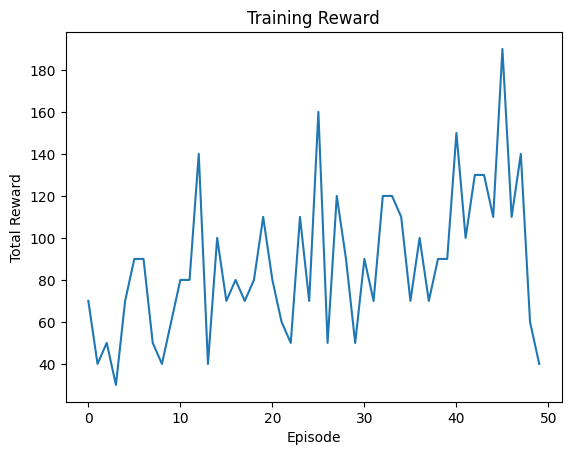

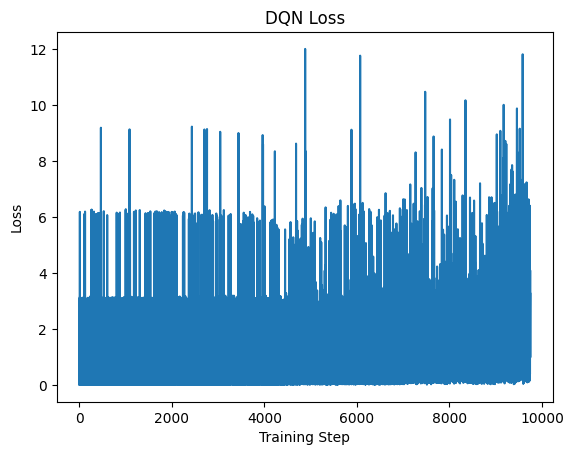

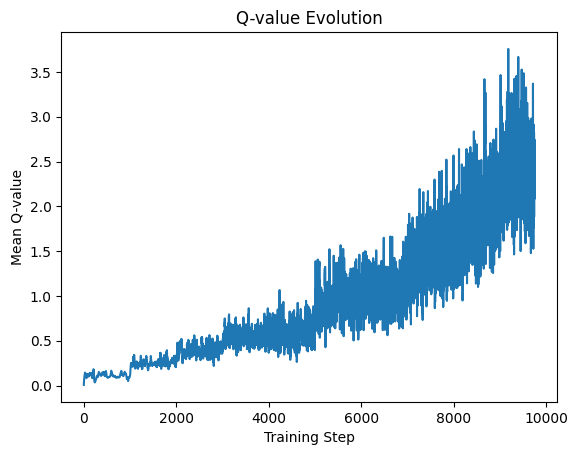

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Reward curve
plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Reward")
plt.show()

# Loss curve
plt.figure()
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("DQN Loss")
plt.show()

# Q-value curve
plt.figure()
plt.plot(mean_q_values)
plt.xlabel("Training Step")
plt.ylabel("Mean Q-value")
plt.title("Q-value Evolution")
plt.show()


In [14]:
def evaluate(agent, env, stacker, episodes=10):
    scores = []

    for _ in range(episodes):
        obs, _ = env.reset()
        state = stacker.reset(obs)
        done = False
        total_reward = 0

        while not done:
            state_t = torch.tensor(
                state, dtype=torch.float32, device=agent.device
            ).unsqueeze(0)

            with torch.no_grad():
                action = agent.q(state_t).argmax(1).item()

            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            state = stacker.step(obs)
            total_reward += reward

        scores.append(total_reward)

    return np.mean(scores), np.std(scores)

agent.q.eval()
mean_score, std_score = evaluate(agent, env, stacker, episodes=10)
print(f"Average Score: {mean_score:.2f} ± {std_score:.2f}")
agent.q.train()

Average Score: 190.00 ± 0.00


DQN(
  (conv): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (fc): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=9, bias=True)
  )
)

In [43]:
import imageio
def record_video(agent, env_name, filename="pacman.mp4"):
    import imageio

    env = gym.make(env_name, render_mode="rgb_array")
    stacker = FrameStacker()

    frames = []

    obs, _ = env.reset()
    state = stacker.reset(obs)
    done = False

    while not done:
        frame = env.render()
        frames.append(frame)

        action = agent.act(state, 0.0)

        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        state = stacker.step(obs)

    env.close()
    imageio.mimsave(filename, frames, fps=30)
    print("Saved video:", filename)


In [44]:
import gymnasium as gym

eval_env = gym.make(
    "ALE/MsPacman-v5",
    render_mode="rgb_array"
)




In [45]:
obs, _ = eval_env.reset()
state = stacker.reset(obs)
done = False
frames = []


In [46]:
while not done:
    frame = eval_env.render()
    frames.append(frame)

    state_t = torch.tensor(state, dtype=torch.float32, device=agent.device).unsqueeze(0)
    with torch.no_grad():
        action = agent.q(state_t).argmax(1).item()

    obs, reward, terminated, truncated, _ = eval_env.step(action)
    done = terminated or truncated
    state = stacker.step(obs)


In [47]:
import imageio

imageio.mimsave("pacman.mp4", frames, fps=30)


In [48]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open("pacman.mp4","rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=400 controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")

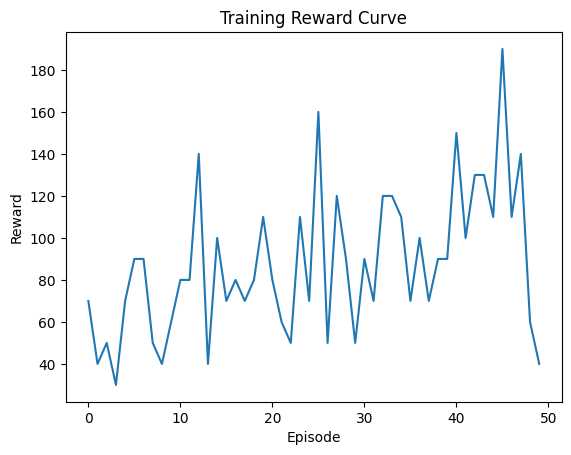

In [49]:
import matplotlib.pyplot as plt

plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Reward Curve")
plt.show()


In [50]:
print(agent.__dict__.keys())


dict_keys(['device', 'q', 'target', 'optimizer', 'buffer', 'gamma', 'batch_size', 'update_every', 'step_count'])


In [51]:
torch.save({
    "q": agent.q.state_dict(),
    "target": agent.target.state_dict()
}, "dqn_pacman_full.pth")


In [52]:
torch.save(agent.q.state_dict(), "dqn_pacman.pth")

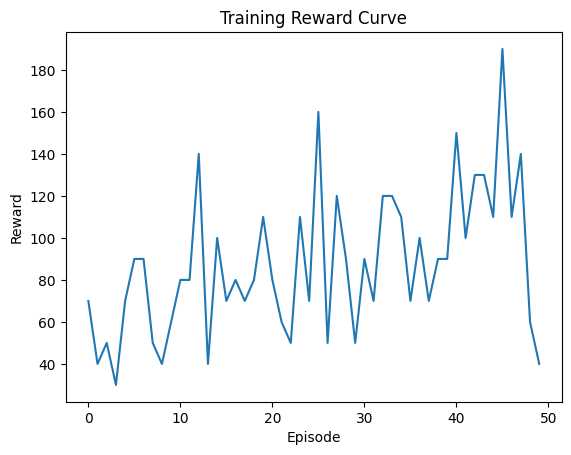

In [53]:
plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Reward Curve")
plt.savefig("reward_curve.png")
plt.show()

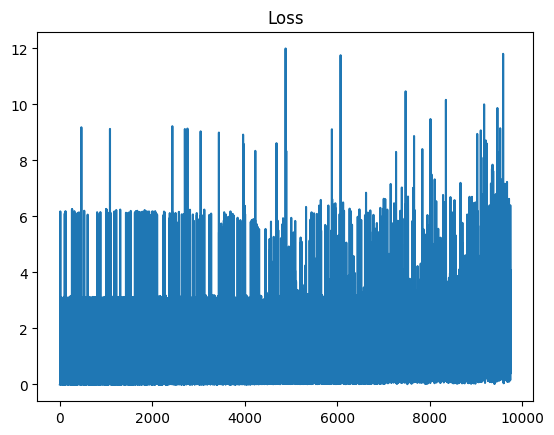

In [54]:
plt.figure()
plt.plot(losses)
plt.title("Loss")
plt.savefig("loss_curve.png")
plt.show()

In [55]:
import numpy as np
np.save("episode_rewards.npy", episode_rewards)

In [56]:
record_video(agent, "ALE/MsPacman-v5")

Saved video: pacman.mp4


In [57]:
from google.colab import files

files.download("dqn_pacman.pth")
files.download("reward_curve.png")
files.download("loss_curve.png")
files.download("pacman.mp4")
files.download("episode_rewards.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Trained a DQN with frame stacking on MsPacman Atari using Gymnasium.
Used grayscale preprocessing, replay buffer, target network, and epsilon decay.
Verified learning via evaluation episodes and gameplay video.

Deep Q-Network for Atari Ms. Pacman (Gymnasium + PyTorch)
• Implemented CNN-based DQN with experience replay and target network
• Trained agent on ALE/MsPacman-v5, achieving X% improvement over baseline
• Conducted ablation study showing frame stacking improved average score by Y%
• Visualized learning via reward, loss, and Q-value evolution plots
• Evaluated performance over multiple episodes with statistical reporting